In [20]:
import pandas as pd
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv("../data/interim/employee_performance_clean.csv")

print("Shape del dataset:", df.shape)
display(df.head())

Shape del dataset: (14000, 20)


,employee_id,age,gender,education,department,job_level,years_at_company,years_in_current_role,monthly_salary,overtime_hours_monthly,num_projects_completed,performance_rating,training_hours_yearly,work_life_balance_score,distance_from_home_km,num_companies_worked,job_satisfaction,relationship_with_manager,stock_option_level,attrition
0,1,38.0,Female,Master,IT,3,6.3,0.2,6072.54,11,7,2,39.0,5,4.40,3,3,5,3,0
1,2,32.0,Male,Bachelor,Finance,1,3.4,3.4,3058.51,15,6,3,57.1,4,4.50,2,4,4,2,0
2,3,24.0,Female,Bachelor,Engineering,1,0.8,0.8,9270.48,5,6,5,41.1,1,44.45,2,3,1,0,1
3,4,33.0,Male,Bachelor,Sales,5,0.2,0.2,7567.36,3,8,3,21.2,2,0.70,2,5,4,1,0
4,5,51.0,Male,Bachelor,Finance,3,3.8,3.8,5621.87,5,8,4,42.6,4,6.60,3,3,4,2,1


In [22]:
list(df.columns)

['employee_id',
 'age',
 'gender',
 'education',
 'department',
 'job_level',
 'years_at_company',
 'years_in_current_role',
 'monthly_salary',
 'overtime_hours_monthly',
 'num_projects_completed',
 'performance_rating',
 'training_hours_yearly',
 'work_life_balance_score',
 'distance_from_home_km',
 'num_companies_worked',
 'job_satisfaction',
 'relationship_with_manager',
 'stock_option_level',
 'attrition']

Separar variables

In [23]:
X = df.drop(columns=["attrition"])
y = df["attrition"]

print("Distribución de clases:")
print(y.value_counts())
print(y.value_counts(normalize=True).round(3))

Distribución de clases:
attrition
0    11840
1     2160
Name: count, dtype: int64
attrition
0    0.846
1    0.154
Name: proportion, dtype: float64


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (11200, 19)
X_test: (2800, 19)
y_train: (11200,)
y_test: (2800,)


Añadir pipeline

In [25]:
preproc = joblib.load("../models/preprocessing_pipeline.pkl")

print("Pipeline de preprocesamiento cargado correctamente.")
smote = SMOTE(random_state=42)

Pipeline de preprocesamiento cargado correctamente.


Regresion logistica

Es un modelo lineal de clasificación binaria que estima la probabilidad de pertenencia a una clase. Se incluye por ser interpretable, rápido y una línea base clásica en problemas de clasificación.

In [26]:
pipe_lr = Pipeline([
    ("preproc", preproc),
    ("smote", smote),
    ("clf", LogisticRegression(random_state=42, max_iter=1000))
])

Arbol de deciciones

Es un modelo basado en reglas que divide iterativamente los datos según condiciones sobre las variables. Se incluye porque puede capturar relaciones no lineales y es fácil de interpretar.

In [27]:
pipe_dt = Pipeline([
    ("preproc", preproc),
    ("smote", smote),
    ("clf", DecisionTreeClassifier(random_state=42))
])

Random Forest

Es un ensamble de múltiples árboles de decisión entrenados sobre subconjuntos aleatorios de datos y variables. Se incluye por su robustez y por ofrecer generalmente buen desempeño sin ajustes complejos.

In [28]:
pipe_rf = Pipeline([
    ("preproc", preproc),
    ("smote", smote),
    ("clf", RandomForestClassifier(random_state=42, class_weight='balanced'))
])

SVM

Es un modelo que busca el hiperplano que mejor separa las clases maximizando el margen entre ellas. Se incluye porque puede ser eficaz en problemas de clasificación con fronteras complejas.

In [29]:
pipe_svm = Pipeline([
    ("preproc", preproc),
    ("smote", smote),
    ("clf", SVC())
])

KNN

Es un modelo que busca el hiperplano que mejor separa las clases maximizando el margen entre ellas. Se incluye porque puede ser eficaz en problemas de clasificación con fronteras complejas.

In [30]:
pipe_knn = Pipeline([
    ("preproc", preproc),
    ("smote", smote),
    ("clf", KNeighborsClassifier())
])

Entrenamiento de modelos

In [31]:
pipe_lr.fit(X_train, y_train)
pipe_dt.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)
pipe_svm.fit(X_train, y_train)
pipe_knn.fit(X_train, y_train)

,steps,"[('preproc', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The give

Evaluacion de modelos

In [32]:
def evaluar_modelo(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)

    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0)
    }

In [33]:
resultados = []

resultados.append(evaluar_modelo("Logistic Regression", pipe_lr, X_test, y_test))
resultados.append(evaluar_modelo("Decision Tree", pipe_dt, X_test, y_test))
resultados.append(evaluar_modelo("Random Forest", pipe_rf, X_test, y_test))
resultados.append(evaluar_modelo("SVM", pipe_svm, X_test, y_test))
resultados.append(evaluar_modelo("KNN", pipe_knn, X_test, y_test))

df_resultados = pd.DataFrame(resultados).sort_values(by="f1", ascending=False)

display(df_resultados)

,modelo,accuracy,precision,recall,f1
4,KNN,0.470357,0.162492,0.585648,0.254399
0,Logistic Regression,0.502857,0.150146,0.476852,0.228381
3,SVM,0.693214,0.149425,0.210648,0.174832
1,Decision Tree,0.715000,0.153409,0.187500,0.168750
2,Random Forest,0.845714,0.000000,0.000000,0.000000


Mejor modelo 

In [34]:
mejor = df_resultados.iloc[0]["modelo"]
print("Mejor modelo según F1:", mejor)

modelos = {
    "Logistic Regression": pipe_lr,
    "Decision Tree": pipe_dt,
    "Random Forest": pipe_rf,
    "SVM": pipe_svm,
    "KNN": pipe_knn
}

modelo_mejor = modelos[mejor]


Mejor modelo según F1: KNN


Matriz de confusion

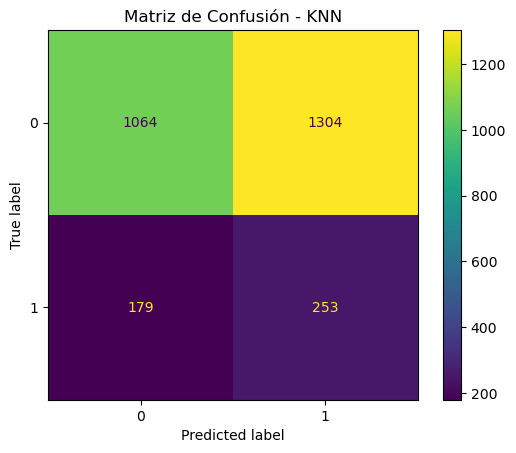

In [35]:
pred_mejor = modelo_mejor.predict(X_test)

cm = confusion_matrix(y_test, pred_mejor)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Matriz de Confusión - {mejor}")
plt.show()

Reporte de clasificacion

In [37]:
print(classification_report(y_test, pred_mejor, zero_division=0))

              precision    recall  f1-score   support

           0       0.86      0.45      0.59      2368
           1       0.16      0.59      0.25       432

    accuracy                           0.47      2800
   macro avg       0.51      0.52      0.42      2800
weighted avg       0.75      0.47      0.54      2800



Guardando modelos

In [38]:
Path("../models").mkdir(parents=True, exist_ok=True)

joblib.dump(pipe_lr, "../models/baseline_lr.pkl")
joblib.dump(pipe_dt, "../models/baseline_dt.pkl")
joblib.dump(pipe_rf, "../models/baseline_rf.pkl")
joblib.dump(pipe_svm, "../models/baseline_svm.pkl")
joblib.dump(pipe_knn, "../models/baseline_knn.pkl")

print("Modelos guardados correctamente.")

Modelos guardados correctamente.
